# Data Visualization

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("books_multiple_pages.csv"
df["Price"] = df["Price"].str.replace(r"[^\d.]", "", regex=True)
df["Price"] = pd.to_numeric(df["Price"], errors="coerce")

rating_map = {"One":1,"Two":2,"Three":3,"Four":4,"Five":5}
df["Rating"] = df["Rating"].map(rating_map)

def get_sentiment(r):
    if r >= 4:
        return "Positive"
    elif r == 3:
        return "Neutral"
    else:
        return "Negative"

df["Sentiment"] = df["Rating"].apply(get_sentiment)

print(df.head())

                                   Title  Price  Rating Sentiment
0                   A Light in the Attic  51.77       3   Neutral
1                     Tipping the Velvet  53.74       1  Negative
2                             Soumission  50.10       1  Negative
3                          Sharp Objects  47.82       4  Positive
4  Sapiens: A Brief History of Humankind  54.23       5  Positive


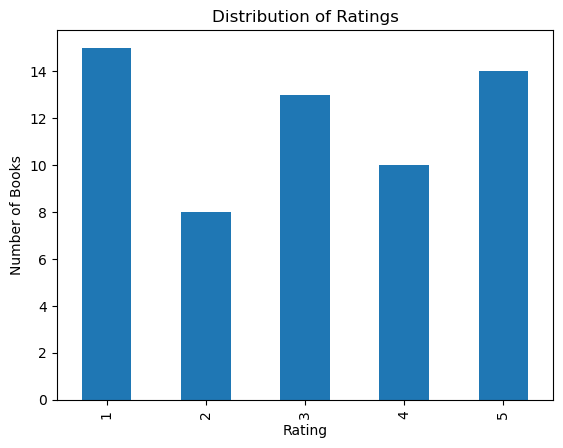

In [2]:
df["Rating"].value_counts().sort_index().plot(kind="bar")
plt.xlabel("Rating")
plt.ylabel("Number of Books")
plt.title("Distribution of Ratings")
plt.show()

conclusion: Ratings 1 and 5 have the highest book counts  while rating 2 is the lowest .

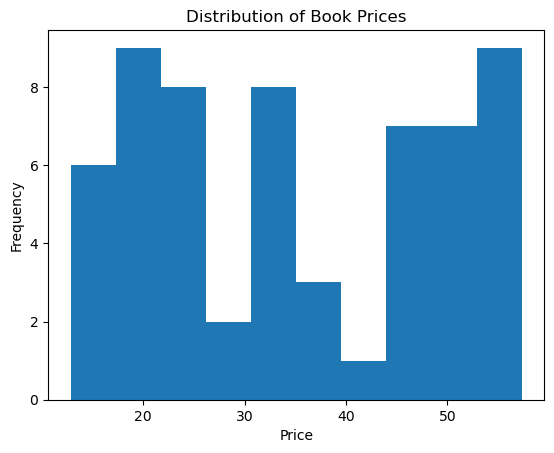

In [3]:
plt.hist(df["Price"], bins=10)
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.title("Distribution of Book Prices")
plt.show()

Most books are priced between ₹15–25 and ₹45–55, with a dip in the middle range 

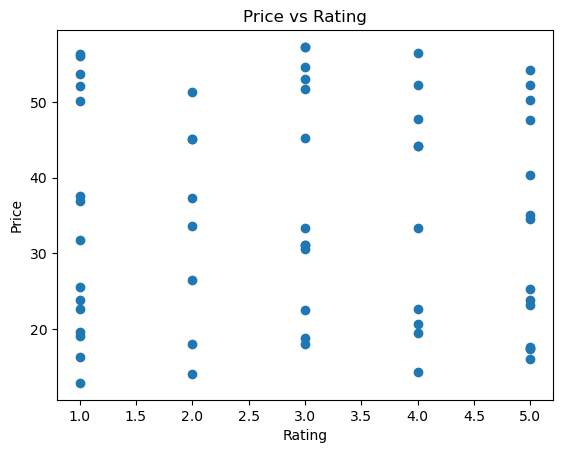

In [4]:
plt.scatter(df["Rating"], df["Price"])
plt.xlabel("Rating")
plt.ylabel("Price")
plt.title("Price vs Rating")
plt.show()

No strong linear relationship between price and rating. Books across all price ranges appear at every rating level, suggesting price does not determine perceived quality.

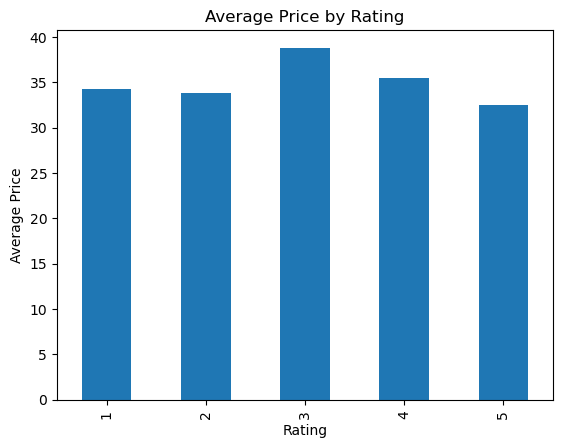

In [5]:
avg_price = df.groupby("Rating")["Price"].mean()

avg_price.plot(kind="bar")
plt.xlabel("Rating")
plt.ylabel("Average Price")
plt.title("Average Price by Rating")
plt.show()

Rating 3 has the highest average price , while rating 5 has the lowest

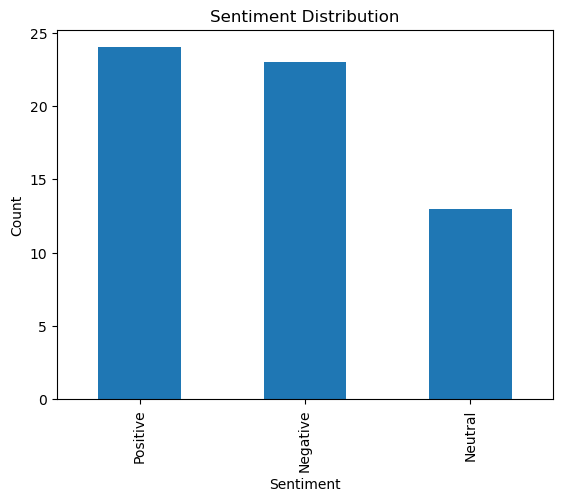

In [6]:
df["Sentiment"].value_counts().plot(kind="bar")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.title("Sentiment Distribution")
plt.show()

Positive and Negative sentiments are nearly equal, while Neutral is lowest . This means reader opinions are polarised — few people feel indifferent about books.

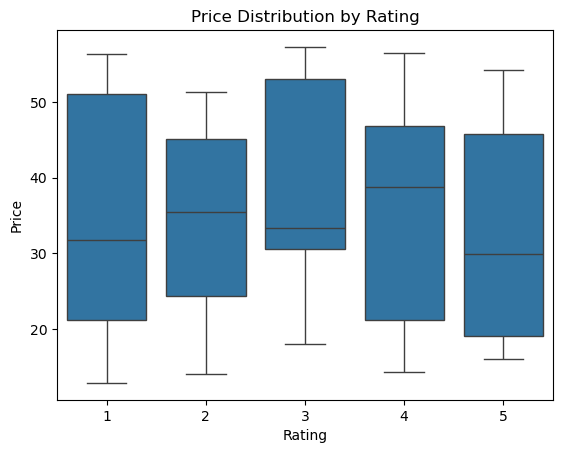

In [8]:
import seaborn as sns

sns.boxplot(x="Rating", y="Price", data=df)
plt.title("Price Distribution by Rating")
plt.show()

All rating groups show a similar price spread (roughly ₹20–55). The median prices are comparable across ratings 1–5, confirming no strong price-rating dependency. Rating 3 shows the widest spread.
